<a href="https://colab.research.google.com/github/yorbisUdeA/udea/blob/main/RegresionLogistica_Accidentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística – Predicción de Gravedad de Accidentes

**Regresión logística** es una variación que se usa para **clasificación binaria** (entre 0 y 1).

Este modelo predice la **gravedad del accidente** (`Heridos=0` / `Muertos=1`) a partir de variables contextuales:
hora, día, tipo de vehículo, condición climática, estado de embriaguez, sector, entre otras.

## **Integrantes:**

*   Santiago Piedrahita - 1040328162
*   Jose Manuel Candamil - 1017144516
*   Yorbis Aragon Bedoya - 1038103291

## 1. Librerías y configuraciones previas

In [31]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestión de librerías
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

# Manejo de desbalanceo de clases
# ==============================================================================
from imblearn.over_sampling import SMOTE

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Interactuar con OS y solicitudes HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [32]:
# Parámetros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'

# Nombre del archivo del dataset
DATASET_FILE_NAME = 'DataSet_Accidentes_500.xlsx'
UTILS_FILE_NAME   = 'funciones.py'

# Directorios
DATASETS_PATH           = 'datasets/'
UTILS_PATH              = 'utils/'
MODELS_PATH             = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

# URLs completas en GitHub
github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url   = os.path.join(GITHUB_BASE_URL, UTILS_PATH,    UTILS_FILE_NAME)

# Rutas locales
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path   = os.path.join(UTILS_PATH,    UTILS_FILE_NAME)


## 2. Funciones

In [33]:
# Función local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url         (str): URL del archivo
        path        (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f'Descargando {description} desde: {url}')
    response = requests.get(url)
    response.raise_for_status()
    with open(path, 'wb') as f:
        f.write(response.content)
    print(f'{description} descargado exitosamente a: {path}')


In [34]:
# Configuración del entorno
# ==============================================================================

# Crear directorios locales
os.makedirs(DATASETS_PATH,             exist_ok=True)
os.makedirs(UTILS_PATH,                exist_ok=True)
os.makedirs(MODELS_PATH,               exist_ok=True)
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH,        exist_ok=True)

# Descarga de archivos desde GitHub
download_file(github_dataset_url, local_dataset_path, 'dataset')
download_file(github_utils_url,   local_utils_path,   'funciones')


Descargando dataset desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/datasets/DataSet_Accidentes_500.xlsx
dataset descargado exitosamente a: datasets/DataSet_Accidentes_500.xlsx
Descargando funciones desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


In [35]:
# Funciones externas del repositorio
# ==============================================================================
sys.path.append(UTILS_PATH)
from funciones import multiple_plot, plot_roc_curve


## 3. Carga del dataset

In [36]:
# Cargar dataset de accidentes
# ==============================================================================
d = pd.read_excel(local_dataset_path)
print(f'📊 Dataset cargado: {d.shape[0]:,} filas × {d.shape[1]} columnas')


📊 Dataset cargado: 500 filas × 32 columnas


In [37]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Radicado              500 non-null    int64         
 1   Fecha_Accidente       500 non-null    datetime64[ns]
 2   Hora_Accidente        500 non-null    object        
 3   Dia_Semana            500 non-null    object        
 4   Año                   500 non-null    int64         
 5   Mes                   500 non-null    int64         
 6   Clase_Vehiculo        500 non-null    object        
 7   Tipo_Servicio         500 non-null    object        
 8   Tipo_Victima          500 non-null    object        
 9   Edad                  500 non-null    int64         
 10  Genero                500 non-null    object        
 11  Gravedad              500 non-null    object        
 12  Estado_Embriaguez     500 non-null    object        
 13  Consumo_Droga       

In [38]:
d.head()


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2180005,2018-01-01,19:00:00,Lunes,2018,1,Motocicleta,Particular,Motociclista,15,...,No Reportado,Comercial,Lluvia,No respetar prelacion,2018-01-01,Noche,2.7090,1.2760,Joven,Adulto
1,2173901,2018-01-02,22:50:00,Martes,2018,1,Motocicleta,Particular,Motociclista,19,...,No Reportado,Comercial,Normal,Desobedecer señales,2018-01-02,Noche,2.9453,1.3034,Joven,Adulto
2,2180000,2018-01-02,20:40:00,Martes,2018,1,Bus,Publico,Pasajero,21,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.0449,1.3152,Joven,Adulto
3,2180000,2018-01-02,20:40:00,Martes,2018,1,Automovil,Particular,Conductor,31,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.4336,1.3621,Adulto,Joven
4,2180008,2018-01-03,09:00:00,Miércoles,2018,1,Motocicleta,Particular,Motociclista,20,...,No Reportado,Residencial,Normal,Impericia en el manejo,2018-01-03,Mañana,2.9961,1.3095,Joven,Adulto


## 4. Selección y transformación de variables

### 4.1 Selección de columnas relevantes

In [39]:
# Variables de entrada y variable objetivo
# ==============================================================================
FEATURES = [
    'Hora_Accidente',
    'Dia_Semana',
    'Mes',
    'Clase_Vehiculo',
    'Tipo_Servicio',
    'Edad',
    'Genero',
    'Estado_Embriaguez',
    'Condicion_Climatica',
    'Sector_Accidente',
    'Localidad_Comuna'
]
TARGET = 'Gravedad'

# Subconjunto de trabajo
d = d[FEATURES + [TARGET]].copy()

print(f'Variables seleccionadas: {len(FEATURES)} entradas + 1 objetivo')
print(f'Shape: {d.shape}')
d.isnull().sum()


Variables seleccionadas: 11 entradas + 1 objetivo
Shape: (500, 12)


,0
Hora_Accidente,0
Dia_Semana,0
Mes,0
Clase_Vehiculo,0
Tipo_Servicio,0
Edad,0
Genero,0
Estado_Embriaguez,0
Condicion_Climatica,0
Sector_Accidente,0


### 4.2 Ingeniería de características

In [40]:
# Extraer hora como entero (0-23) desde formato 'HH:MM:SS'
# ==============================================================================
d['Hora_Accidente'] = d['Hora_Accidente'].astype(str).str.split(':').str[0].astype(int)

# Agrupar comunas/localidades con menos de 80 registros como 'Otro'
# (reduce dimensionalidad del one-hot encoding)
# ==============================================================================
top_comunas = d['Localidad_Comuna'].value_counts()
top_comunas = top_comunas[top_comunas >= 80].index
d['Localidad_Comuna'] = d['Localidad_Comuna'].apply(
    lambda x: x if x in top_comunas else 'Otro'
)

print(f'Comunas con >= 80 registros mantenidas: {len(top_comunas)}')
print(f'Resto agrupado como "Otro"')
d.head(3)


Comunas con >= 80 registros mantenidas: 1
Resto agrupado como "Otro"


,Hora_Accidente,Dia_Semana,Mes,Clase_Vehiculo,Tipo_Servicio,Edad,Genero,Estado_Embriaguez,Condicion_Climatica,Sector_Accidente,Localidad_Comuna,Gravedad
0,19,Lunes,1,Motocicleta,Particular,15,Mujer,No,Lluvia,Comercial,Las Vegas,Heridos
1,22,Martes,1,Motocicleta,Particular,19,Hombre,No,Normal,Comercial,Otro,Heridos
2,20,Martes,1,Bus,Publico,21,Mujer,No,Lluvia,Residencial,Otro,Heridos


### 4.3 Variable objetivo – Codificación binaria

In [41]:
# Distribución original de la variable objetivo
# ==============================================================================
print('Distribución de Gravedad (original):')
print(d[TARGET].value_counts())
print(f'\nProporción Muertos: {(d[TARGET]=="Muertos").mean()*100:.2f}%')

# Codificación: Muertos = 1 (clase positiva), Heridos = 0
d[TARGET] = (d[TARGET] == 'Muertos').astype(int)

print('\nCodificación aplicada → Muertos=1, Heridos=0')
print(d[TARGET].value_counts())


Distribución de Gravedad (original):
Gravedad
Heridos    370
Muertos    130
Name: count, dtype: int64

Proporción Muertos: 26.00%

Codificación aplicada → Muertos=1, Heridos=0
Gravedad
0    370
1    130
Name: count, dtype: int64


## 5. Visualización de datos

### Variables de entrada

In [42]:
# Separar variables categóricas y numéricas
# ==============================================================================
catCols = d.select_dtypes(include=['object', 'category']).columns.tolist()
numCols = d.select_dtypes(include=['float64','int32','int64']).columns.tolist()
numCols = [c for c in numCols if c != TARGET]

print('Variables categóricas:', catCols)
print('Variables numéricas  :', numCols)
d[catCols].head(2)


Variables categóricas: ['Dia_Semana', 'Clase_Vehiculo', 'Tipo_Servicio', 'Genero', 'Estado_Embriaguez', 'Condicion_Climatica', 'Sector_Accidente', 'Localidad_Comuna']
Variables numéricas  : ['Hora_Accidente', 'Mes', 'Edad']


,Dia_Semana,Clase_Vehiculo,Tipo_Servicio,Genero,Estado_Embriaguez,Condicion_Climatica,Sector_Accidente,Localidad_Comuna
0,Lunes,Motocicleta,Particular,Mujer,No,Lluvia,Comercial,Las Vegas
1,Martes,Motocicleta,Particular,Hombre,No,Normal,Comercial,Otro


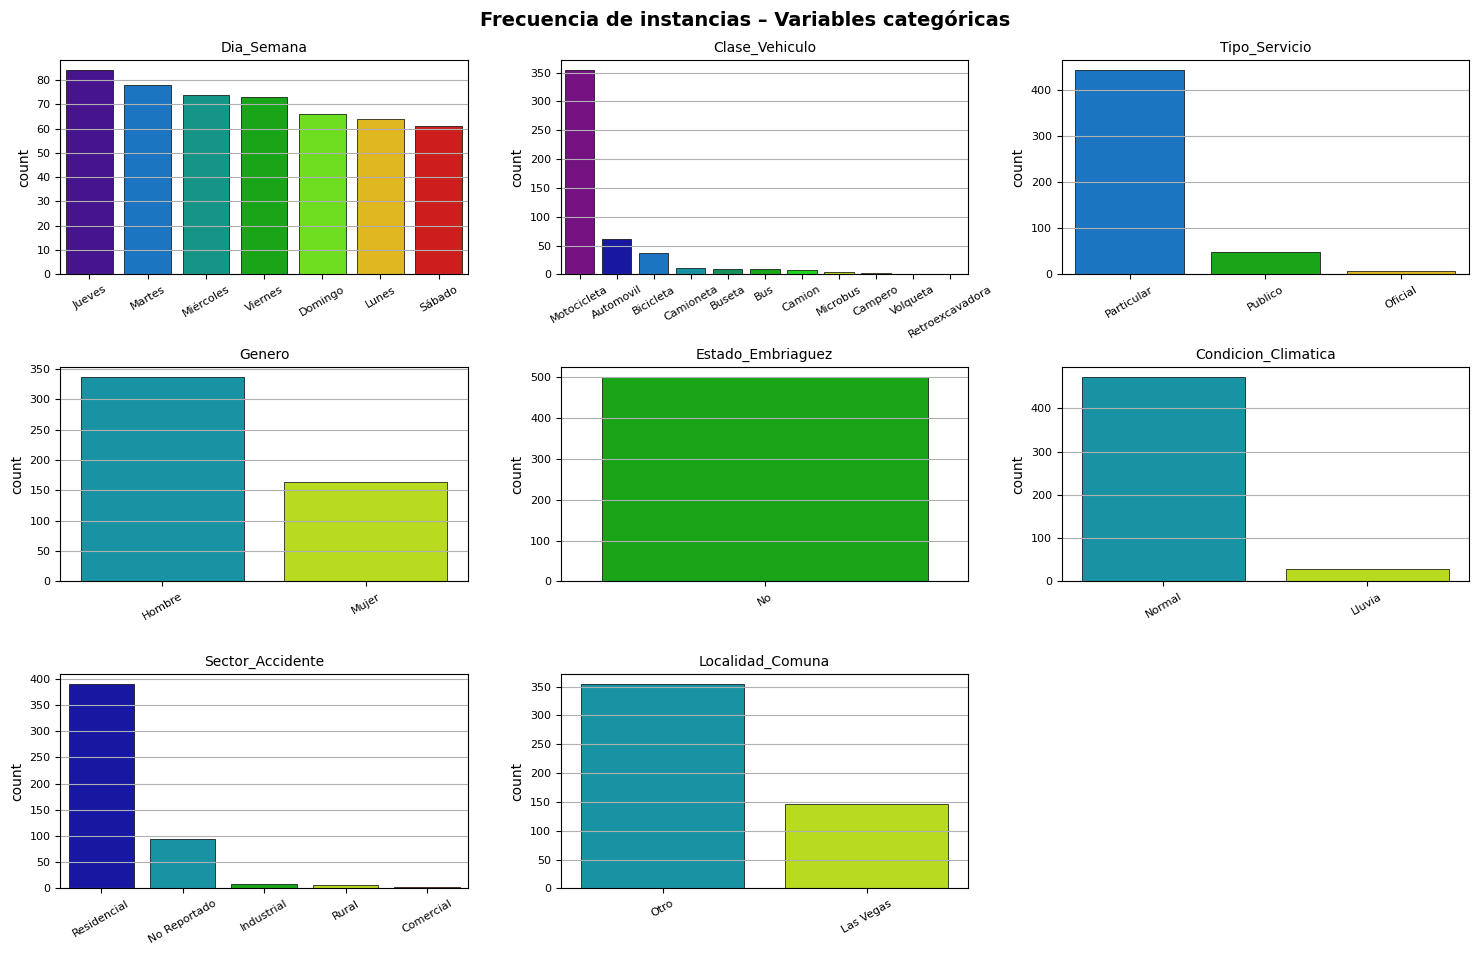

In [43]:
# Visualización de frecuencia para variables categóricas
# ==============================================================================
multiple_plot(3, d, catCols, None, 'countplot',
              'Frecuencia de instancias – Variables categóricas', 30)


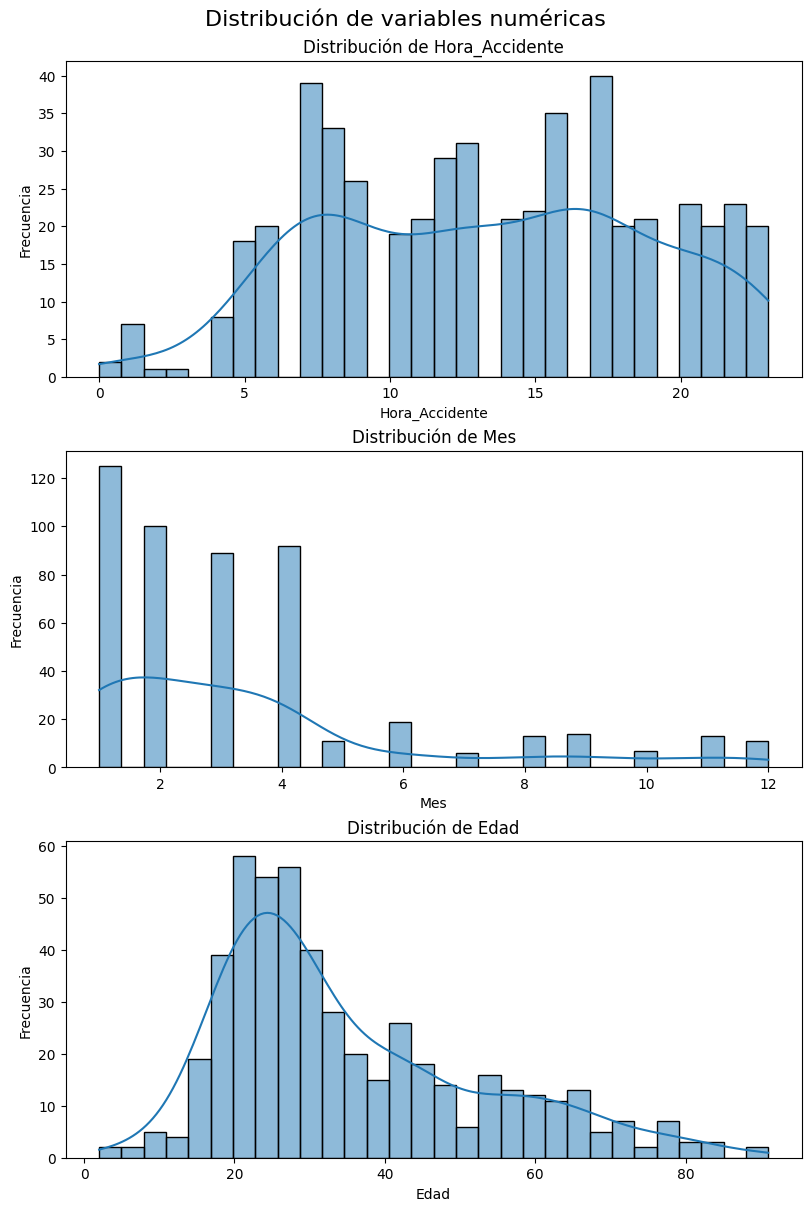

In [44]:
# Visualización de variables numéricas
# ==============================================================================

nrows = len(numCols)
fig, axes = plt.subplots(nrows, 1, figsize=(8, nrows * 4), constrained_layout=True)
fig.suptitle('Distribución de variables numéricas', fontsize=16)

# Ensure axes is an iterable (list of Axes objects) even if there's only one subplot
if nrows == 1:
    axes = [axes]

for i, col in enumerate(numCols):
    sns.histplot(data=d, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.show()

### Variable de salida

In [45]:
# Distribución de la variable de salida
# ==============================================================================
d.groupby(TARGET)[TARGET].count().sort_values(ascending=False)


,Gravedad
Gravedad,
0,370
1,130


⚠️ Dataset desbalanceado: solo 26.00% son Muertos (clase=1).
   Se aplicará SMOTE para balancear clases en el entrenamiento.


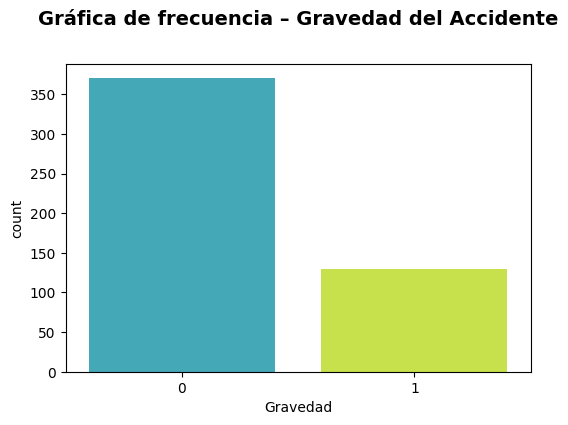

In [46]:
# Gráfico de la variable de salida
# ==============================================================================
multiple_plot(1, d, None, TARGET, 'countplot',
              'Gráfica de frecuencia – Gravedad del Accidente', 0)

print(f'⚠️ Dataset desbalanceado: solo {d[TARGET].mean()*100:.2f}% son Muertos (clase=1).')
print('   Se aplicará SMOTE para balancear clases en el entrenamiento.')


## 6. Transformación de datos

### Creación de variables Dummies

In [47]:
# Aplicar One-Hot Encoding a variables categóricas
# drop_first=True evita multicolinealidad perfecta
# ==============================================================================
d = pd.get_dummies(d, drop_first=True)

d.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Hora_Accidente                  500 non-null    int64
 1   Mes                             500 non-null    int64
 2   Edad                            500 non-null    int64
 3   Gravedad                        500 non-null    int64
 4   Dia_Semana_Jueves               500 non-null    bool 
 5   Dia_Semana_Lunes                500 non-null    bool 
 6   Dia_Semana_Martes               500 non-null    bool 
 7   Dia_Semana_Miércoles            500 non-null    bool 
 8   Dia_Semana_Sábado               500 non-null    bool 
 9   Dia_Semana_Viernes              500 non-null    bool 
 10  Clase_Vehiculo_Bicicleta        500 non-null    bool 
 11  Clase_Vehiculo_Bus              500 non-null    bool 
 12  Clase_Vehiculo_Buseta           500 non-null    bool 
 13  Clase

## 7. Creación del modelo

### Dividir el conjunto de datos

In [48]:
# Lista de variables de entrada
# ==============================================================================
vDep = list(d.columns)
vDep.remove(TARGET)

# Variables de entrada X y variable de salida y
X = d.drop(columns=TARGET)
y = d[TARGET]


In [49]:
# División 80% entrenamiento – 20% prueba (estratificada)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1, 1),
    train_size=0.8,
    random_state=123,
    shuffle=True,
    stratify=y       # mantiene proporción de clases en ambos splits
)

print(f'Entrenamiento : {X_train.shape[0]:,} muestras  |  Muertos: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Prueba         : {X_test.shape[0]:,} muestras   |  Muertos: {y_test.sum()} ({y_test.mean()*100:.1f}%)')


Entrenamiento : 400 muestras  |  Muertos: 104 (26.0%)
Prueba         : 100 muestras   |  Muertos: 26 (26.0%)


### Escalar Variables

In [50]:
# Variables numéricas a escalar (las dummies ya están en 0/1)
# ==============================================================================
num_vars = ['Hora_Accidente', 'Mes', 'Edad']
print('Variables a escalar:', num_vars)


Variables a escalar: ['Hora_Accidente', 'Mes', 'Edad']


In [51]:
# Escalar variables numéricas
# Ajuste SOLO con datos de entrenamiento → evita data leakage
# ==============================================================================
pd.set_option('display.float_format', lambda x: '%.4f' % x)

scaler = MinMaxScaler()
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars]  = scaler.transform(X_test[num_vars])

# Guardar scaler
joblib.dump(scaler, os.path.join(MODELS_SCALER_PATH, 'scaler_accidentes.pkl'))
print('Scaler guardado.')
X_train[num_vars].describe()


Scaler guardado.


,Hora_Accidente,Mes,Edad
count,400.0000,400.0000,400.0000
mean,0.5813,0.2295,0.3754
std,0.2459,0.2527,0.1938
min,0.0000,0.0000,0.0000
25%,0.3478,0.0909,0.2360
50%,0.5652,0.1818,0.3146
75%,0.7826,0.2727,0.4831
max,1.0000,1.0000,1.0000


### Balanceo de clases con SMOTE

In [52]:
# El dataset tiene ~98.6% Heridos y ~1.4% Muertos → desbalanceo extremo
# SMOTE genera muestras sintéticas de la clase minoritaria (Muertos)
# IMPORTANTE: SMOTE se aplica SOLO al conjunto de entrenamiento
# ==============================================================================
smote = SMOTE(random_state=123)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train.ravel())

print(f'Antes  → {X_train.shape[0]:,} muestras  |  Muertos: {y_train.sum()}')
print(f'Después→ {X_train_bal.shape[0]:,} muestras  |  Muertos: {y_train_bal.sum():,}')
print(f'Nueva proporción clase positiva: {y_train_bal.mean()*100:.1f}%')


Antes  → 400 muestras  |  Muertos: 104
Después→ 592 muestras  |  Muertos: 296
Nueva proporción clase positiva: 50.0%


### Ajuste del modelo

In [53]:
# Entrenamiento del modelo de Regresión Logística
# ==============================================================================
modelo = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=123
)

modelo.fit(X_train_bal, y_train_bal)

# Guardar modelo
joblib.dump(modelo, os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes.pkl'))
print('Modelo entrenado y guardado.')


Modelo entrenado y guardado.


## 8. Evaluación del modelo

In [54]:
# Predicciones sobre el conjunto de prueba
# ==============================================================================
y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]   # probabilidad de la clase positiva (Muertos)

print(f'Muertos predichos : {y_pred.sum()}')
print(f'Muertos reales    : {y_test.sum()}')


Muertos predichos : 24
Muertos reales    : 26


### Reporte de clasificación

In [55]:
# Métricas completas
# ==============================================================================
print(classification_report(
    y_test, y_pred,
    target_names=['Heridos (0)', 'Muertos (1)']
))
print(f'F1-Score (Muertos): {f1_score(y_test, y_pred):.4f}')


              precision    recall  f1-score   support

 Heridos (0)       0.91      0.93      0.92        74
 Muertos (1)       0.79      0.73      0.76        26

    accuracy                           0.88       100
   macro avg       0.85      0.83      0.84       100
weighted avg       0.88      0.88      0.88       100

F1-Score (Muertos): 0.7600


### Matriz de confusión

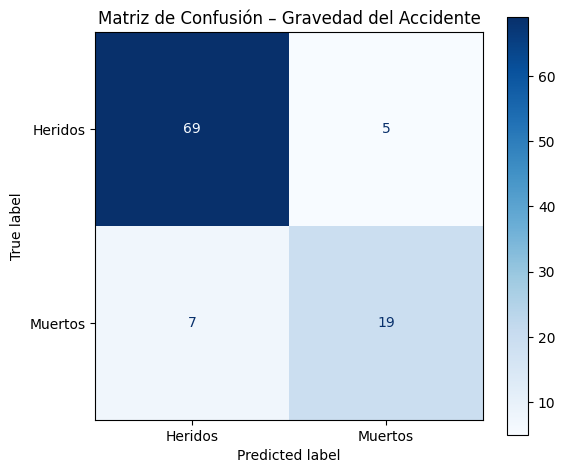

Verdaderos Negativos (Heridos correctos): 69
Falsos Positivos   (Heridos → Muertos)  : 5
Falsos Negativos   (Muertos → Heridos)  : 7
Verdaderos Positivos (Muertos correctos): 19


In [56]:
# Matriz de confusión
# ==============================================================================
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Heridos', 'Muertos']
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión – Gravedad del Accidente', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (Heridos correctos): {tn}')
print(f'Falsos Positivos   (Heridos → Muertos)  : {fp}')
print(f'Falsos Negativos   (Muertos → Heridos)  : {fn}')
print(f'Verdaderos Positivos (Muertos correctos): {tp}')


### Curva ROC y AUC

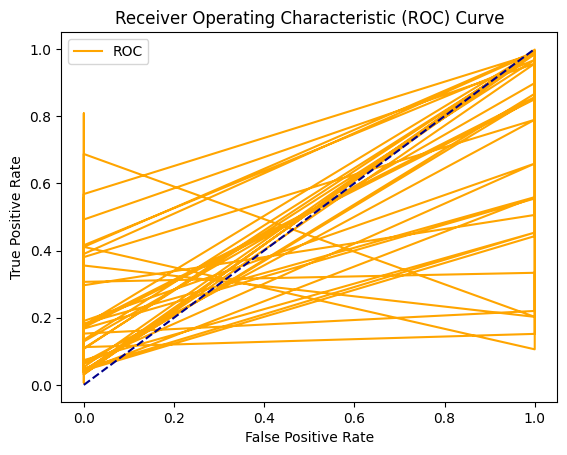

AUC-ROC: 0.9018


In [57]:
# Curva ROC
# ==============================================================================

auc = roc_auc_score(y_test, y_proba)
plot_roc_curve(y_test, y_proba) # Keep this to display the plot

print(f'AUC-ROC: {auc:.4f}')

## 9. Interpretación del modelo

### Coeficientes del modelo (Importancia de variables)

In [58]:
# Tabla de coeficientes ordenada por magnitud absoluta
# ==============================================================================
coef_df = pd.DataFrame({
    'Variable'   : X.columns,
    'Coeficiente': modelo.coef_[0]
})
coef_df['Abs_Coef']   = coef_df['Coeficiente'].abs()
coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

print('Top 20 variables más influyentes:')
coef_df.head(20)


Top 20 variables más influyentes:


,Variable,Coeficiente,Abs_Coef,Odds_Ratio
0,Mes,7.3344,7.3344,1532.1393
1,Edad,2.0631,2.0631,7.8703
2,Sector_Accidente_Industrial,1.7660,1.7660,5.8474
3,Sector_Accidente_Rural,1.7009,1.7009,5.4786
4,Clase_Vehiculo_Camioneta,1.4000,1.4000,4.0551
5,Sector_Accidente_Residencial,-1.0404,1.0404,0.3533
6,Tipo_Servicio_Particular,0.8815,0.8815,2.4145
7,Clase_Vehiculo_Retroexcavadora,0.7991,0.7991,2.2236
8,Clase_Vehiculo_Microbus,0.7112,0.7112,2.0364
9,Clase_Vehiculo_Buseta,0.5568,0.5568,1.7451


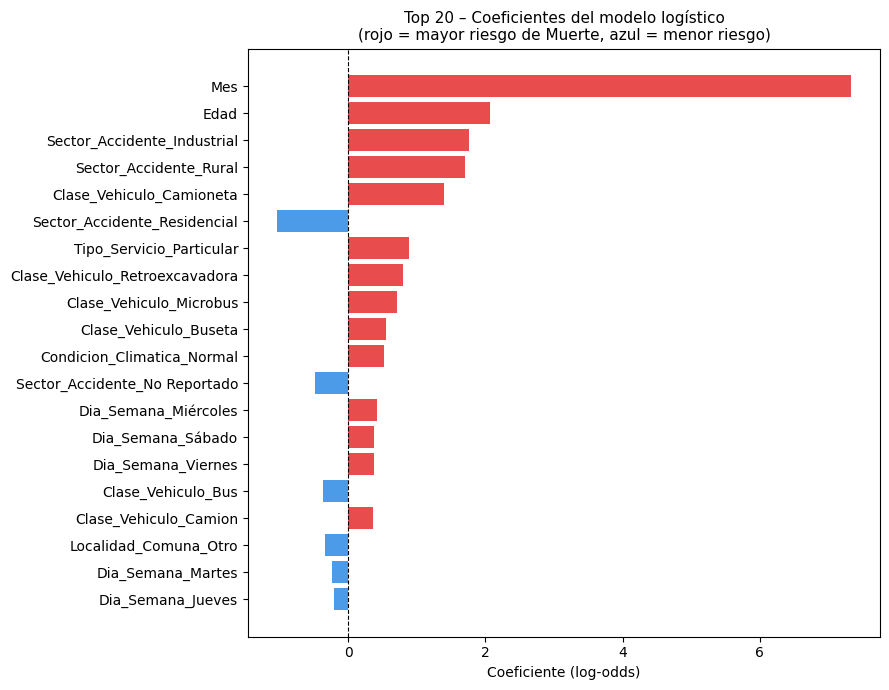

In [59]:
# Gráfico de coeficientes – Top 20
# ==============================================================================
top20  = coef_df.head(20)
colors = ['#E84C4C' if c > 0 else '#4C9BE8' for c in top20['Coeficiente']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20['Variable'][::-1], top20['Coeficiente'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Top 20 – Coeficientes del modelo logístico\n(rojo = mayor riesgo de Muerte, azul = menor riesgo)', fontsize=11)
plt.tight_layout()
plt.show()


## 10. Predicción sobre nuevos datos

In [60]:
# Ejemplo: cargar modelo y scaler guardados y predecir
# ==============================================================================
modelo_cargado = joblib.load(os.path.join(MODELS_CLASIFICACION_PATH, 'logistic_accidentes.pkl'))
scaler_cargado = joblib.load(os.path.join(MODELS_SCALER_PATH,        'scaler_accidentes.pkl'))

# Usar la primera muestra del conjunto de prueba como ejemplo
nueva_muestra = X_test.iloc[[0]].copy()

pred_clase = modelo_cargado.predict(nueva_muestra)[0]
pred_prob  = modelo_cargado.predict_proba(nueva_muestra)[0]

print(f'Predicción  : {"Muertos (1)" if pred_clase == 1 else "Heridos (0)"}')
print(f'Prob Heridos: {pred_prob[0]*100:.2f}%')
print(f'Prob Muertos: {pred_prob[1]*100:.2f}%')


Predicción  : Heridos (0)
Prob Heridos: 81.67%
Prob Muertos: 18.33%


## 11. Conclusiones

| Métrica | Clase | Descripción |
|---|---|---|
| **AUC-ROC** | Global | Capacidad discriminante del modelo |
| **Recall** | Muertos | % de muertes reales detectadas (crítico) |
| **Precisión** | Muertos | % de predicciones "Muerto" que son correctas |
| **F1-Score** | Muertos | Balance entre Recall y Precisión |

**Hallazgos clave:**

- El dataset presenta un **desbalanceo extremo** (~98.6% Heridos vs 1.4% Muertos). Se aplicó **SMOTE** exclusivamente sobre el conjunto de entrenamiento para no contaminar la evaluación.
- Las variables más influyentes (mayor coeficiente absoluto) son el **tipo de vehículo** y la **hora del accidente**.
- En problemas de seguridad vial, maximizar el **Recall de Muertos** es prioritario sobre la precisión: es más costoso no detectar un accidente fatal que generar una falsa alarma.
- Como trabajo futuro se recomienda explorar **Random Forest** o **XGBoost** con ajuste de umbral de decisión y validación cruzada estratificada para mejorar la detección de la clase minoritaria.
